# HMC Data Analysis

## Load in Packages and data

In [1]:
import arviz as az # for reading in the netcdf file and plotting
import matplotlib.pyplot as plt # for plotting
import numpy as np # for numerical operations
from globalfit_functions import * # for the physical model
import seaborn as sns # for plotting
import xarray as xr
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from scipy.optimize import curve_fit
from scipy import odr
import pandas as pd # for data manipulation


filename = r"BTD_Yang_Stoichiometric_WU5000_SAM5000_nobkg_noAug.nc"
variable_names = ["Trapping", "Bimolecular", "Detrapping", "Depopulation", "Trap Density"]
units = [f'cm$^3$ns$^{{-1}}$', f'cm$^3$ns$^{{-1}}$', f'ns$^{{-1}}$', f'cm$^3$ns$^{{-1}}$', f'cm$^3$']
converter = [0,0,0,0,0] #Convert from um to um units
# true_values = [1e-37, 1e-18, 1e-19, 1e-4, 1e-18, 1e16]

idata = az.from_netcdf(filename)

Posterior mean: [-17.03167467 -18.55717832  -3.17454791 -19.05096696  15.37195296]


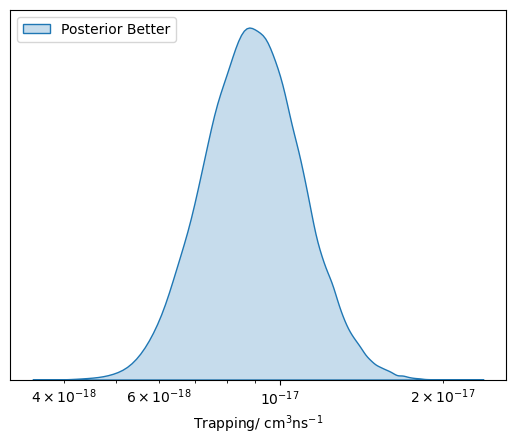

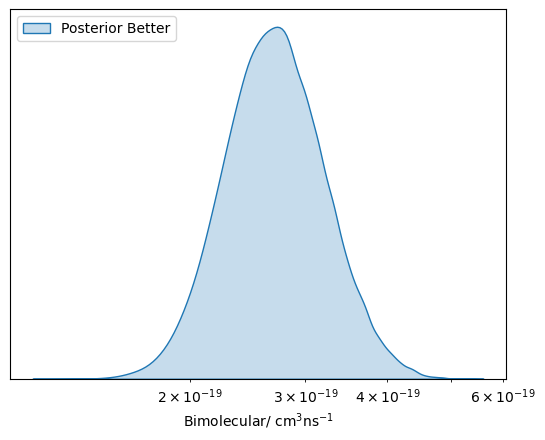

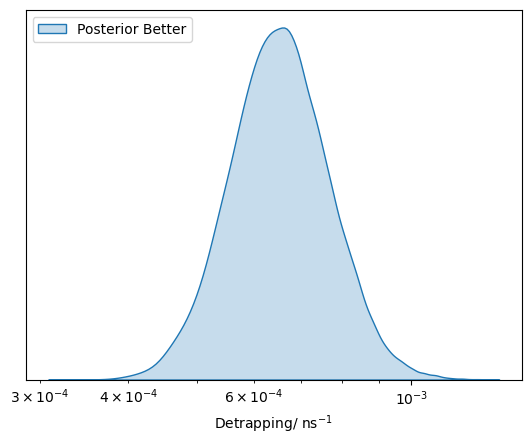

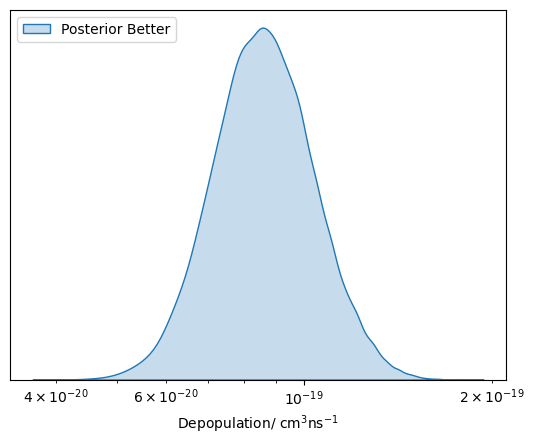

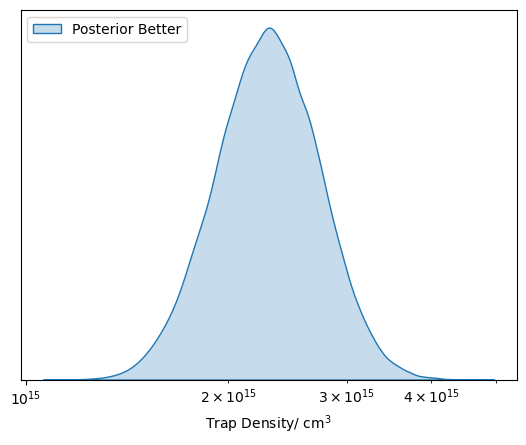

In [2]:
theta_posterior = idata.posterior.theta.values
# theta_prior = idataspacing.prior.theta.values
#Mean theta across chains
# theta_prior_mean = np.mean(theta_prior, axis=0).mean(axis=0)
theta_posterior_mean = np.mean(theta_posterior, axis=0).mean(axis=0)
# print("Prior mean:", theta_prior_mean)
print("Posterior mean:", theta_posterior_mean)

#Plot posterior and prior distributions
priors_log = []
posteriors_log = []
priors = []
posteriors = []


for i in range(theta_posterior.shape[-1]): 
    # Extract data for the i-th parameter across ALL chains and draws
    posterior_allchains = theta_posterior[:,:,i]

    # --- THE FIX ---
    # Flatten the (n_chains, n_draws) array into a single 1D array of all samples
    flat = posterior_allchains.flatten()

    # Plot ONCE using the flattened data
    sns.kdeplot(10**(flat + converter[i]), label='Posterior Better', fill=True)   
    
    # Formatting
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.legend(loc='upper left')
    plt.xscale('log')
    plt.xlabel(f'{variable_names[i]}/ {units[i]}')
    plt.show()
    

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
n01            1.003  0.005   0.995    1.012      0.000    0.000    2348.0   
n02            1.004  0.005   0.996    1.013      0.000    0.000    2353.0   
n03            0.999  0.005   0.990    1.008      0.000    0.000    2373.0   
n04            0.997  0.005   0.988    1.006      0.000    0.000    2370.0   
Trapping     -17.032  0.090 -17.202  -16.863      0.002    0.001    2848.0   
Bimolecular  -18.557  0.076 -18.698  -18.412      0.002    0.001    2354.0   
Detrapping    -3.175  0.070  -3.308   -3.044      0.001    0.000   15043.0   
Depopulation -19.051  0.080 -19.203  -18.900      0.002    0.001    2498.0   
Trap Density  15.372  0.076  15.229   15.515      0.002    0.001    2332.0   

              ess_tail  r_hat  
n01             4953.0    1.0  
n02             4954.0    1.0  
n03             5039.0    1.0  
n04             4991.0    1.0  
Trapping        6433.0    1.0  
Bimolecular     4977.0    1

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
n01,1.003,0.005,0.995,1.012,0.000,0.000,2348.0,4953.0,1.0
n02,1.004,0.005,0.996,1.013,0.000,0.000,2353.0,4954.0,1.0
n03,0.999,0.005,0.990,1.008,0.000,0.000,2373.0,5039.0,1.0
n04,0.997,0.005,0.988,1.006,0.000,0.000,2370.0,4991.0,1.0
Trapping,-17.032,0.090,-17.202,-16.863,0.002,0.001,2848.0,6433.0,1.0
Bimolecular,-18.557,0.076,-18.698,-18.412,0.002,0.001,2354.0,4977.0,1.0
Detrapping,-3.175,0.070,-3.308,-3.044,0.001,0.000,15043.0,18507.0,1.0
Depopulation,-19.051,0.080,-19.203,-18.900,0.002,0.001,2498.0,5408.0,1.0
Trap Density,15.372,0.076,15.229,15.515,0.002,0.001,2332.0,4876.0,1.0


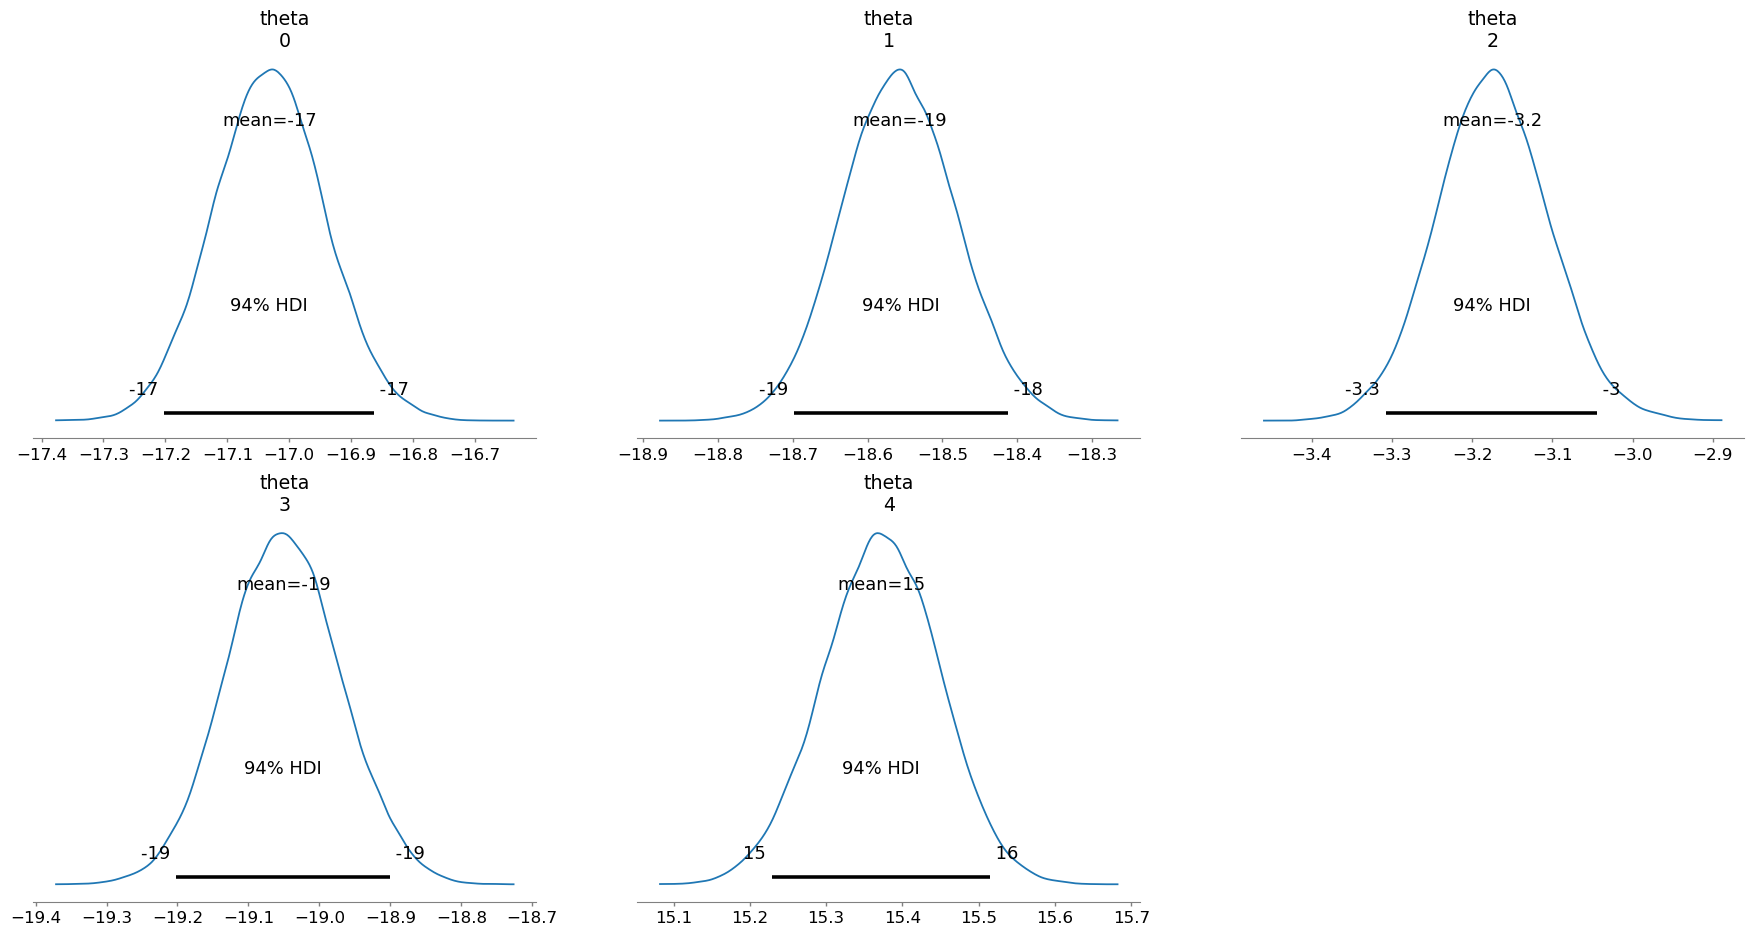

In [3]:
# Adjust the summaries to include names
summary_posterior = az.summary(idata, var_names=["fac","theta"], group="posterior")
summary_posterior.index = ['n01', 'n02', 'n03', 'n04'] + variable_names
# summary_prior = az.summary(idata, var_names=["theta"], group="prior")
# summary_prior.index = variable_names

# Plot prior with updated names
# az.plot_posterior(idata.prior, var_names=["theta"], textsize=12)

# Print prior summary with variable names
# print(summary_prior)

# Plot posterior with updated names
az.plot_posterior(idata.posterior, var_names=["theta"], textsize=12)

# Print posterior summary with variable names
print(summary_posterior)
#Save both in one CSV file
# combined_summary = pd.concat([summary_prior, summary_posterior], axis=1)
# combined_summary.to_csv(f"PriorPosteriorSummary_{filename[:-3]}.csv")
summary_posterior

## Plot Traces to see which chains are problematic

In [4]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from scipy import stats

# Get the original data
theta = idata.posterior['theta']

# Apply converter + power of 10
# Assuming theta has dimensions (chain, draw, theta_dim_0)
theta_values = theta.values
converter_array = np.array(converter)
theta_converted = 10 ** (theta_values + converter_array[np.newaxis, np.newaxis, :])

# Get dimensions
num_chains, num_draws, num_params = theta_converted.shape

# Create subplots: 2 columns (density + trace) for each parameter
fig = make_subplots(
    rows=num_params,
    cols=2,
    subplot_titles=[title for pair in 
                   [(f"{variable_names[i]} - Density", f"{variable_names[i]} - Trace") 
                    for i in range(num_params)] for title in pair],
    horizontal_spacing=0.08,
    vertical_spacing=0.05,
    column_widths=[0.3, 0.7]
)

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for param_idx in range(num_params):
    for chain_idx in range(num_chains):
        chain_data = theta_converted[chain_idx, :, param_idx]
        color = colors[chain_idx % len(colors)]
        
        # Left plot: Density (KDE curve)
        # Create KDE in log space for better representation
        log_data = np.log10(chain_data)
        kde = stats.gaussian_kde(log_data)
        
        # Create evaluation points in log space
        log_min, log_max = log_data.min(), log_data.max()
        log_range = log_max - log_min
        log_points = np.linspace(log_min - 0.1*log_range, log_max + 0.1*log_range, 200)
        
        # Evaluate KDE
        density = kde(log_points)
        
        # Convert back to linear space for plotting
        x_points = 10**log_points
        
        fig.add_trace(
            go.Scatter(
                x=x_points,
                y=density,
                mode='lines',
                name=f"Chain {chain_idx + 1}",
                line=dict(color=color, width=2),
                fill='tozeroy',
                opacity=0.5,
                legendgroup=f"chain{chain_idx}",
                showlegend=(param_idx == 0),  # Only show legend for first parameter
                hovertemplate=(
                    f"<b>Chain {chain_idx + 1}</b><br>" +
                    f"{variable_names[param_idx]}: %{{x:.3e}} {units[param_idx]}<br>" +
                    "Density: %{y:.3e}<br>" +
                    "<extra></extra>"
                )
            ),
            row=param_idx + 1,
            col=1
        )
        
        # Right plot: Trace
        fig.add_trace(
            go.Scatter(
                x=np.arange(num_draws),
                y=chain_data,
                mode='lines',
                name=f"Chain {chain_idx + 1}",
                line=dict(color=color, width=1),
                legendgroup=f"chain{chain_idx}",
                showlegend=False,
                hovertemplate=(
                    f"<b>Chain {chain_idx + 1}</b><br>" +
                    "Step: %{x}<br>" +
                    f"{variable_names[param_idx]}: %{{y:.3e}} {units[param_idx]}<br>" +
                    "<extra></extra>"
                )
            ),
            row=param_idx + 1,
            col=2
        )

# Update axes
for param_idx in range(num_params):
    # Left plot (density) - log scale
    fig.update_xaxes(
        title_text=f"{variable_names[param_idx]} / {units[param_idx]}",
        type="log",
        row=param_idx + 1,
        col=1
    )
    fig.update_yaxes(
        title_text="Density",
        row=param_idx + 1,
        col=1
    )
    
    # Right plot (trace) - log scale on y
    fig.update_xaxes(
        title_text="Steps",
        row=param_idx + 1,
        col=2
    )
    fig.update_yaxes(
        title_text=f"{variable_names[param_idx]} / {units[param_idx]}",
        type="log",
        row=param_idx + 1,
        col=2
    )

# Update layout
fig.update_layout(
    height=400 * num_params,
    width=1500,
    showlegend=True,
    legend=dict(
        title="Chain",
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.01
    ),
    hovermode='closest',
    title_text="MCMC Trace Plots",
    title_x=0.5
)

# Use browser rendering if in Jupyter, otherwise use default
try:
    fig.show()
except ValueError:
    # If nbformat is not installed, open in browser instead
    fig.show(renderer="browser")

## Discard Chains if they are clearly diverged from others

In [5]:
discard_chains = []  # Chain indexes to discard
discard_chains = [num-1 for num in discard_chains]  # Chain indexes to discard
if discard_chains:
    idata_subset = idata.sel(chain=[i for i in range(len(idata.posterior.chain)) if i not  in discard_chains])

    # Recompute summary for prior and posterior
    summary_posterior = az.summary(idata_subset, var_names=["theta"], group="posterior")
    # summary_prior = az.summary(idata_subset, var_names=["theta"], group="prior")

    # Plot posterior for the prior and posterior distributions (excluding chains 1 and 9)
    # az.plot_posterior(idata_subset.prior, var_names=["theta"])
    # print(summary_prior)
    az.plot_posterior(idata_subset.posterior, var_names=["theta"])
    print(summary_posterior)

    # Plot trace with customization
    axes = az.plot_trace(
        idata_subset, 
        var_names=["theta"], 
        compact=False, 
        figsize=(15, 9),  # Increase figure size
    )

    # Ensure proper color mapping for legends
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]  # Get default color cycle
    num_chains = len(idata_subset.posterior.chain)  # Number of chains

    # Iterate over the axes to add legends for both left and right plots
    for i, ax_row in enumerate(axes):
        ax_left, ax_right = ax_row  # Left and right plots in each row
        
        # Add legend to the left plot
        if hasattr(ax_left, "lines") and ax_left.lines:
            ax_left.legend(
                handles=[plt.Line2D([0], [0], color=colors[j % len(colors)], lw=2) for j in range(num_chains)],  # Use modulo to cycle colors
                labels=[f"Chain {j}" for j in range(num_chains)],
                title="Line Index",
                loc="upper right",
                fontsize="xx-small"
            )
        
        # Add legend to the right plot
        if hasattr(ax_right, "lines") and ax_right.lines:
            ax_right.legend(
                handles=[plt.Line2D([0], [0], color=colors[j % len(colors)], lw=2) for j in range(num_chains)],  # Use modulo to cycle colors
                labels=[f"Chain {j}" for j in range(num_chains)],
                title="Line Index",
                loc="upper right",
                fontsize="xx-small"
            )
    idata = idata_subset
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

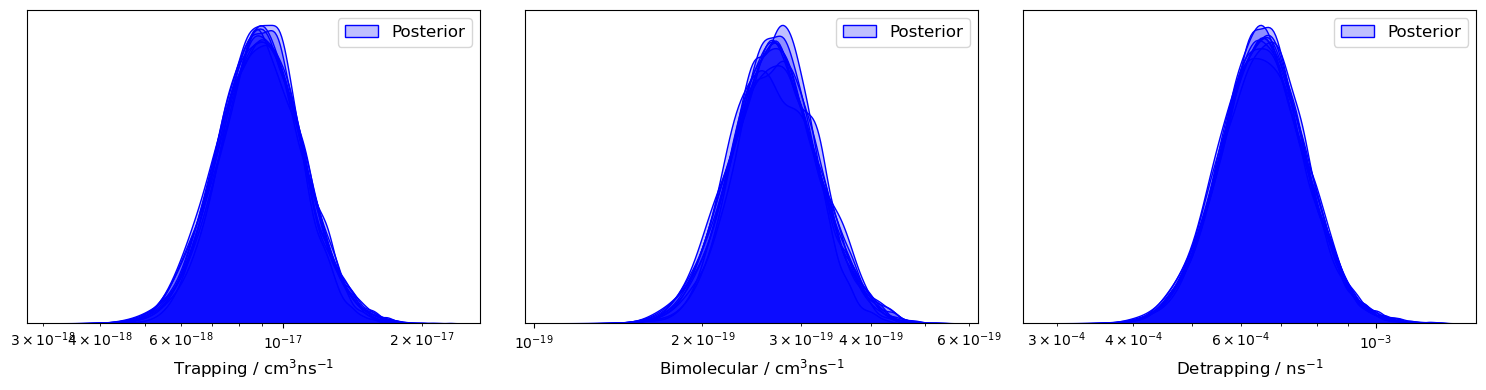

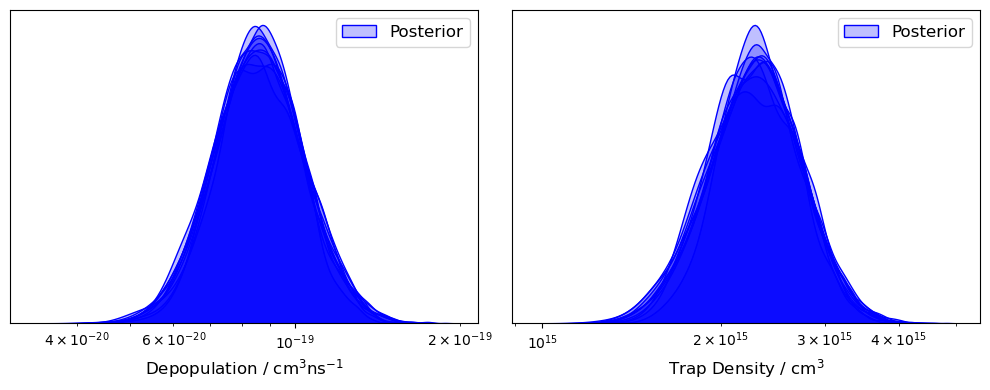

In [6]:
# Extract posterior and prior samples
theta_posterior = idata.posterior.theta.values
# theta_prior = idata.prior.theta.values

priors = []
posteriors = []


def plot_prior_posterior(variable_names, units, true_values, theta_prior, theta_posterior, converter, filename="prior_posterior"):
    n_params = len(variable_names)

    # Define layouts depending on number of params
    layouts = {
        3: [(1, 3)],
        4: [(2, 2)],
        5: [(1, 3), (1, 2)],
        6: [(2, 3)],
        7: [(1, 3), (2, 2)]
    }

    if n_params not in layouts:
        raise ValueError(f"No layout rule defined for {n_params} parameters")

    priors, posteriors = [], []
    param_idx = 0  # keep track of which parameter we are plotting

    for fig_idx, (rows, cols) in enumerate(layouts[n_params], start=1):
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        axes = np.atleast_1d(axes).flatten()

        for ax in axes[:min(cols*rows, n_params - param_idx)]:
            i = param_idx
            posterior_allchains = theta_posterior[:, :, i]
            posteriors.append(posterior_allchains)

            # Plot posteriors for each chain
            for j in range(posterior_allchains.shape[0]):
                sns.kdeplot(
                    10**(posterior_allchains[j] + converter[i]),
                    label='Posterior' if j == 0 else None,
                    fill=True,
                    color='blue',
                    ax=ax
                )

            # --- FIX: Move these OUTSIDE the true_values check ---
            ax.set_xscale('log')
            ax.get_yaxis().set_visible(False)
            ax.set_xlabel(f'{variable_names[i]} / {units[i]}', fontsize='large')
            
            # Only add vertical line if true_values exists
            if true_values is not None:
                 ax.axvline(true_values[i], color='black', linestyle='--', label='True Value')
            
            # Call legend after everything (including the true value line) is added
            ax.legend(fontsize='large')
            
            param_idx += 1

        plt.tight_layout()

        # Save figure
        if len(layouts[n_params]) > 1:
            save_name = f"PriorPosterior_{filename[:-3]}_{fig_idx}.png"
        else:
            save_name = f"PriorPosterior_{filename}.png"

        # plt.savefig(save_name, dpi=300, bbox_inches="tight")
        plt.show(fig)  # close to avoid showing multiple in notebooks

plot_prior_posterior(variable_names, units, true_values=None, theta_prior=None, theta_posterior=theta_posterior, converter=converter, filename=filename)

<xarray.Dataset> Size: 5MB
Dimensions:      (chain: 10, draw: 5000, fac_dim_0: 4, noise_dim_0: 4,
                  theta_dim_0: 5)
Coordinates:
  * chain        (chain) int64 80B 0 1 2 3 4 5 6 7 8 9
  * draw         (draw) int64 40kB 0 1 2 3 4 5 ... 4994 4995 4996 4997 4998 4999
  * fac_dim_0    (fac_dim_0) int64 32B 0 1 2 3
  * noise_dim_0  (noise_dim_0) int64 32B 0 1 2 3
  * theta_dim_0  (theta_dim_0) <U12 240B 'Trapping' ... 'Trap Density'
Data variables:
    fac          (chain, draw, fac_dim_0) float64 2MB 1.013 1.014 ... 1.004
    noise        (chain, draw, noise_dim_0) float64 2MB ...
    theta        (chain, draw, theta_dim_0) float64 2MB 6.721e-18 ... 3.022e+15
Attributes:
    created_at:                 2026-02-24T20:39:08.661453+00:00
    arviz_version:              0.21.0
    inference_library:          numpyro
    inference_library_version:  0.18.0
Edges: [ 0  4  8 12]
Bottom: [12 13 14 15]


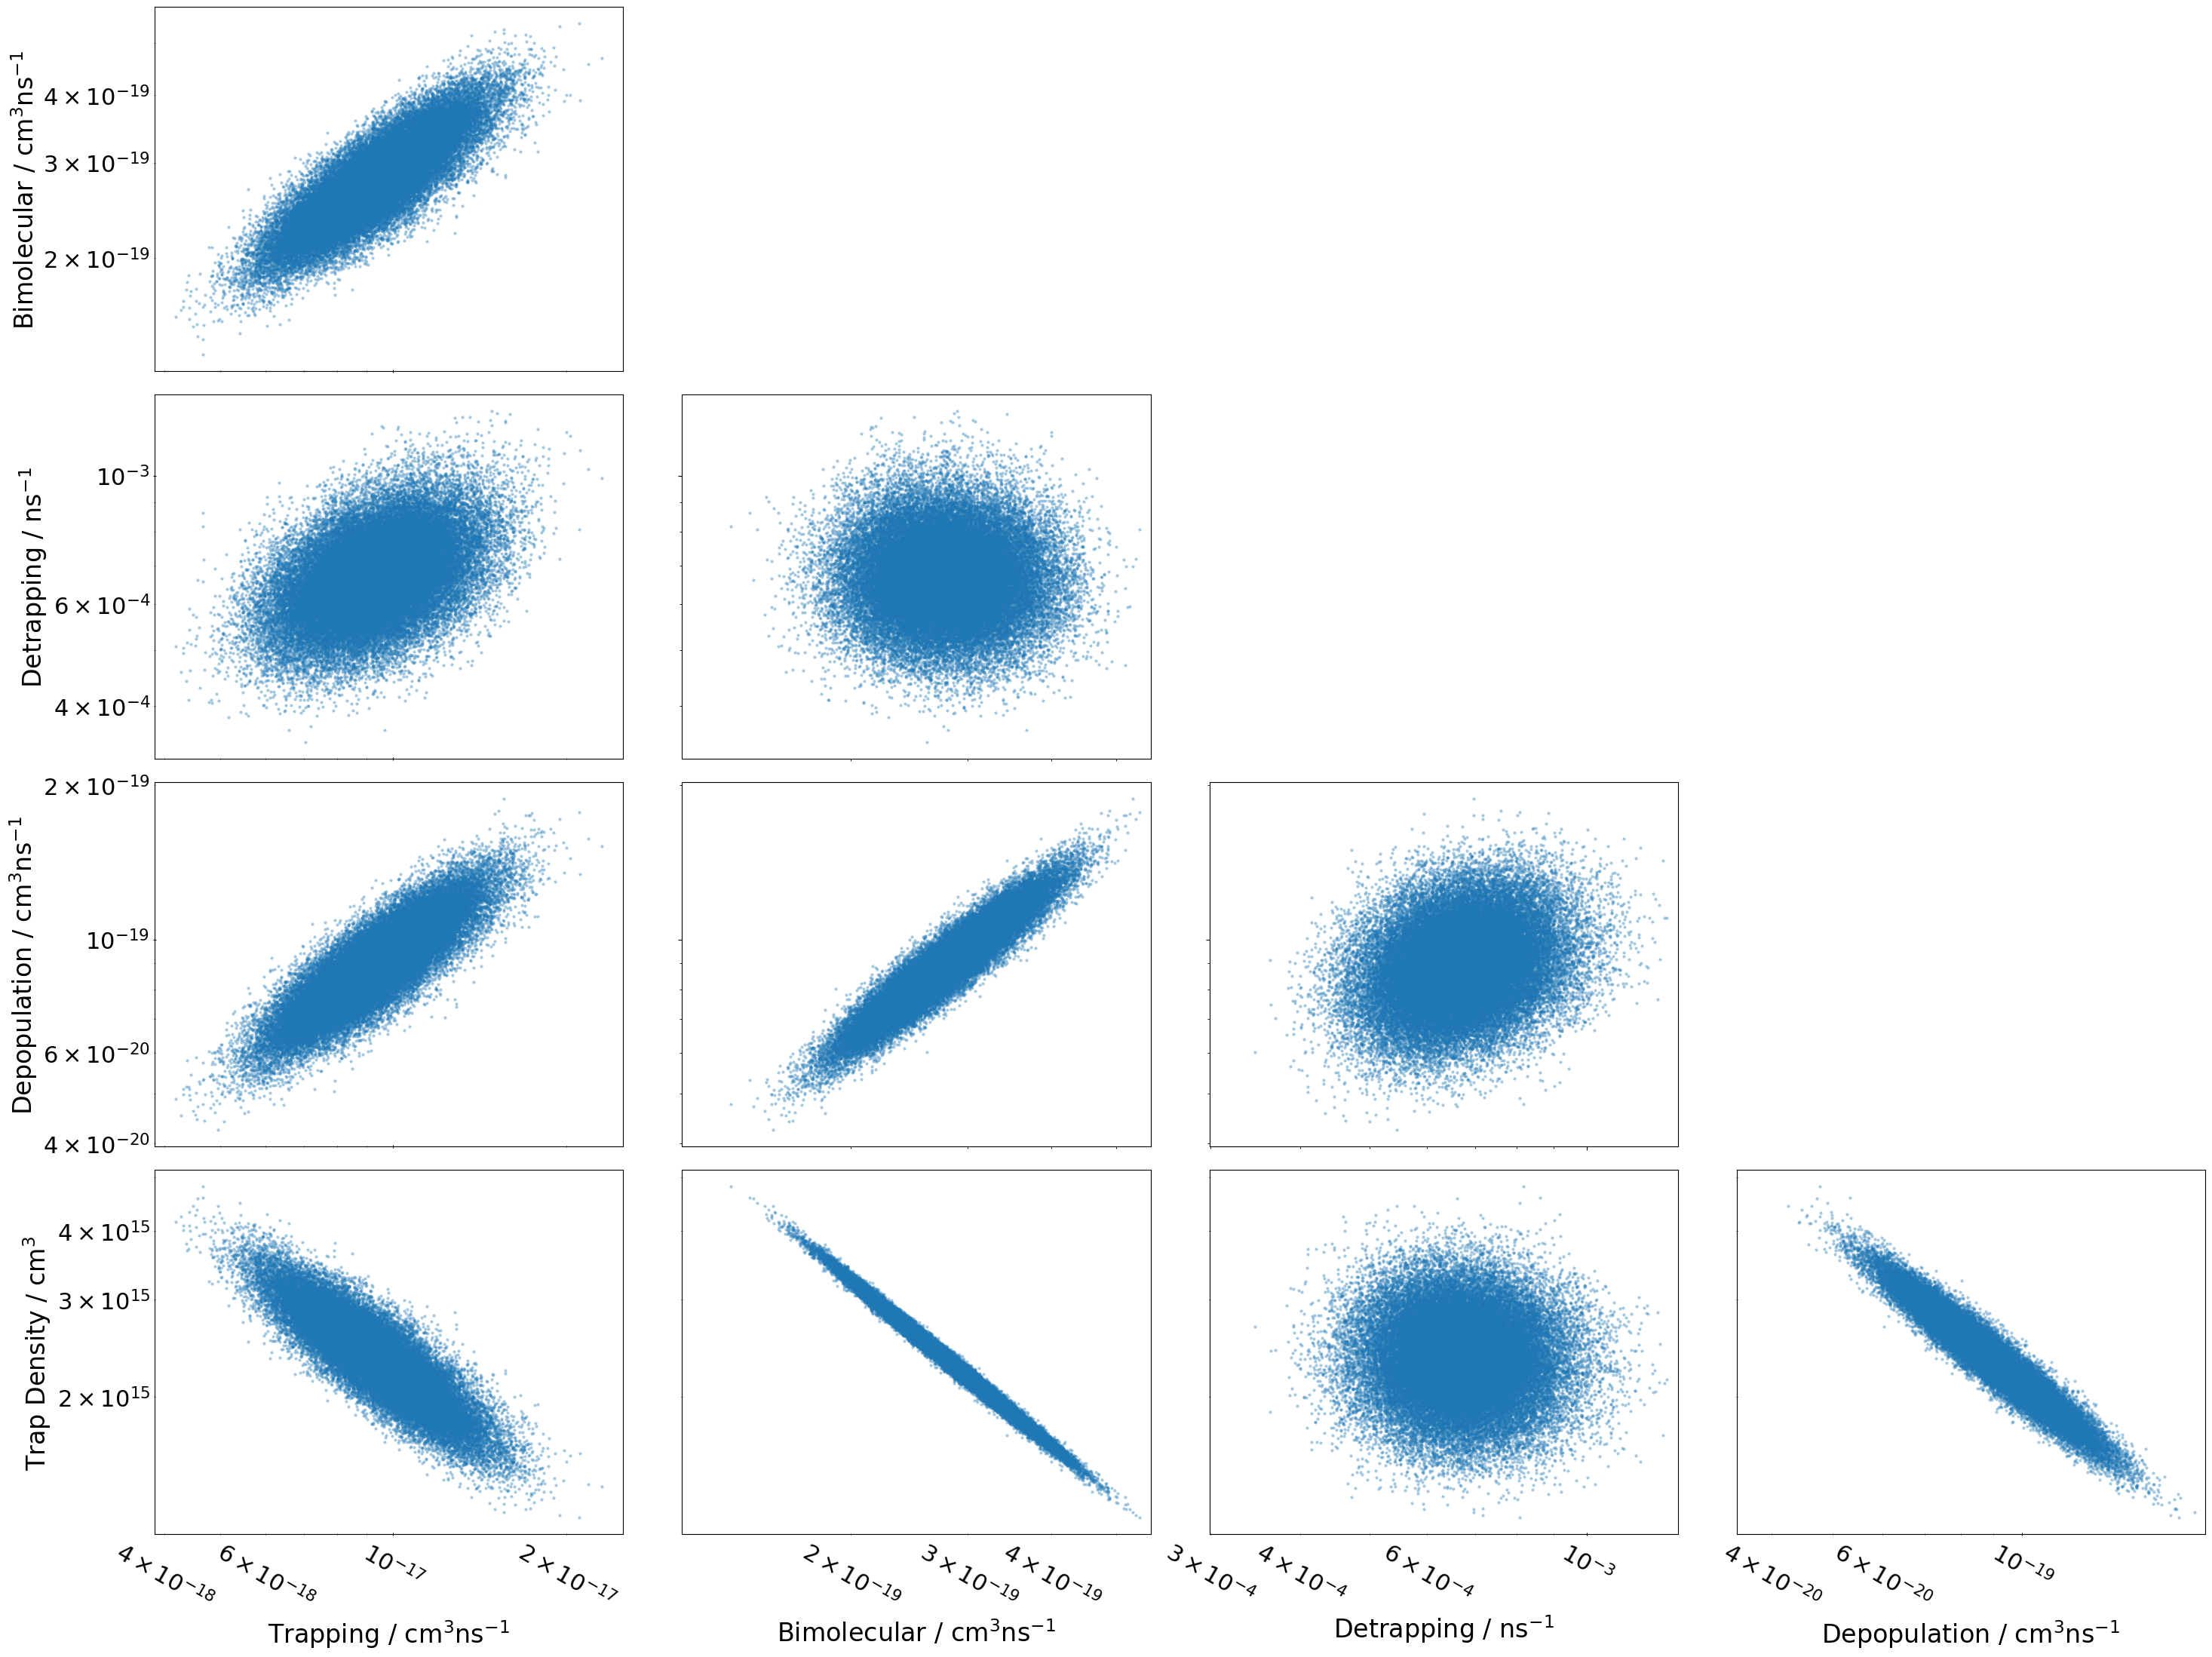

In [7]:
# Get the original data
theta = idata.posterior['theta']

# Apply converter + power of 10
# Assuming shape is (chain, draw, subvariable) and converter matches subvariable length
theta_converted = 10 ** (theta + xr.DataArray(converter, dims=["theta_dim_0"]))
#make abnsolute values for negative rate coefficients
theta_converted = np.abs(theta_converted)
# Create a copy of idata with transformed theta
idata_transformed = idata.copy()
idata_transformed.posterior['theta'] = theta_converted

# Assign coordinates to the transformed data (not the original idata)
idata_transformed.posterior = idata_transformed.posterior.assign_coords(
    theta_dim_0=variable_names
)
print(idata_transformed.posterior)

# Create pair plot with alpha=0.5
axes = az.plot_pair(
    idata_transformed,
    var_names=["theta"],
    group="posterior",
    kind='scatter',
    scatter_kwargs={'alpha': 0.4}
)

shape_1d = axes.shape[0]
total_shape = axes.flatten().shape[0]

edges = np.linspace(0, total_shape - shape_1d, shape_1d).astype(int)
print('Edges:', edges)
bottom = np.linspace(total_shape - shape_1d, total_shape-1, shape_1d).astype(int)
print('Bottom:', bottom)

axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, ax in enumerate(axes.flatten()):
    if ax is None:
        continue
    ax.set_ylabel(f"{variable_names[1+i//shape_1d]} / {units[1+i//shape_1d]}" if i in edges else None, fontsize=24)
    ax.set_xlabel(f"{variable_names[i-bottom[0]]} / {units[i-bottom[0]]}" if i in bottom else None, fontsize=24)
    ax.set_xscale('log')
    ax.set_yscale('log')
    if i in edges or i in bottom:
        ax.tick_params(axis="y", which="both",labelsize=22, direction="inout")  # numeric size
        ax.tick_params(axis="x", which="both",labelsize=22, direction="inout", labelrotation=-30)  # numeric size
        ax.tick_params(axis="x", which="minor",labelsize=22, direction="inout", labelrotation=-30)  # numeric size

plt.tight_layout()
plt.savefig(f'pair_plot_{filename[:-3]}.png', dpi=300)
plt.show()


Mean Values: 9.29663e-18, 2.77218e-19, 6.69040e-04, 8.89269e-20, 2.35479e+15
[np.float64(6.273332136582998e+16), np.float64(3.2492657323622256e+16), np.float64(1.0515582241096594e+16), np.float64(4907950011183904.0)]

True (scaled) n0 values used for simulation:
Decay 1: 6.27e+16 cm^-3
Decay 2: 3.25e+16 cm^-3
Decay 3: 1.05e+16 cm^-3
Decay 4: 4.91e+15 cm^-3
kt: [np.float64(6.281759297341846e-18), np.float64(1.370512490961776e-17)], kb: [np.float64(2.0039263444467936e-19), np.float64(3.8689122410852503e-19)], kdt: [np.float64(0.0004924378945721759), np.float64(0.0009038711289272083)], kdp: [np.float64(6.272329775299926e-20), np.float64(1.2585398403922937e-19)], NT: [np.float64(1692959048775417.0), np.float64(3274196155954774.5)], bkg: 0


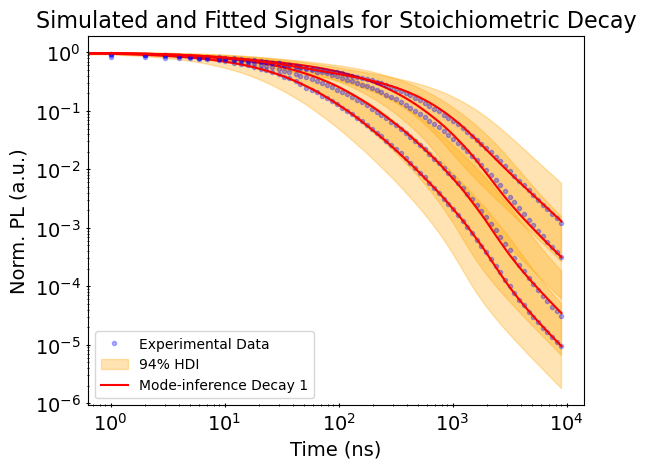

Trapping Constant =  0.02189163953136082 cm^3/ns
NR Bimolecular Constant =  2.9097738613854094e-18 cm^3/ns
Radiative Bimolecular Constant =  2.7721816258930395e-19 cm^3/ns
kNR/kB 10.496331965435509


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from scipy.stats import gaussian_kde

# Load the simulated data
simulated_data = np.load(r'Stoi_Decays.npy')
# print(simulated_data)
n0s = [1.09e+17, 4.99e+16, 1.58e+16, 8.23e+15]
time = simulated_data[0]

# Extract posterior samples
theta = idata.posterior.theta.values  # shape: (chains, draws, parameters)
theta = theta.reshape(-1, theta.shape[-1])  # flatten to (samples, parameters)

kt_mean_log, kb_mean_log, kdt_mean_log, kdp_mean_log, NT_mean_log = np.mean(theta, axis=0)

print(f'Mean Values: {10**kt_mean_log:.5e}, {10**kb_mean_log:.5e}, {10**kdt_mean_log:.5e}, {10**kdp_mean_log:.5e}, {10**NT_mean_log:.5e}')
fac_samples = idata.posterior.fac.values
fac_samples = fac_samples.reshape(-1, fac_samples.shape[-1])  # flatten to (samples, 4)
fac_means = np.mean(fac_samples, axis=0)  # mean for each decay
original_n0s = [5.50e+16, 2.75e+16, 1.10e+16, 5.50e+15]
true_n0s = [10**(np.log10(orig) * f) for orig, f in zip(original_n0s, fac_means)]
# 4. Extract Factor HDIs (for the fill_between simulation)
fac_hdi = az.hdi(idata.posterior.fac, hdi_prob=0.94).to_array().values[0]
print(true_n0s)
print('\nTrue (scaled) n0 values used for simulation:')
for i, val in enumerate(true_n0s):
    print(f"Decay {i+1}: {val:.2e} cm^-3")

# Calculate HDI in log-space
hdi = az.hdi(idata.posterior.theta, hdi_prob=0.94).to_array().values[0]

# Map HDI to transformed space
kt_hdi = [10**(h) for h in hdi[0]]
kb_hdi = [10**(h) for h in hdi[1]]
kdt_hdi = [10**(h) for h in hdi[2]]
kdp_hdi = [10**(h) for h in hdi[3]]
NT_hdi = [10**(h) for h in hdi[4]]
# bkg_hdi = [10**(h) for h in hdi[6]]

# Print HDIs for reference
print(f"kt: {kt_hdi}, kb: {kb_hdi}, kdt: {kdt_hdi}, kdp: {kdp_hdi}, NT: {NT_hdi}, bkg: {0}")
# n0s = [n0 for n0 in n0s]  # Convert from cm^-3 to m^-3
# Simulate and plot results
for i in range(1, len(simulated_data)):
    signal = simulated_data[i]
    time = simulated_data[0]
    
    # Use the specific true_n0 and fac_hdi for this specific index (i-1)
    current_n0_mode = true_n0s[i-1]
    
    # Calculate n0 bounds based on HDI for 'fac'
    # Low factor HDI -> Low n0; High factor HDI -> High n0
    n0_low_hdi = 10**(np.log10(original_n0s[i-1]) * fac_hdi[i-1, 0])
    n0_high_hdi = 10**(np.log10(original_n0s[i-1]) * fac_hdi[i-1, 1])

    # Simulation calls using the correct index-specific n0
    # Note: Using 0 for Auger (ka) as per your MCMC script
    sim_low = 10**TRPL_Extended_Model(time, 0, kt_hdi[0], kb_hdi[0], kdt_hdi[0], kdp_hdi[0], NT_hdi[0], 0, n0_low_hdi, 0)
    sim_high = 10**TRPL_Extended_Model(time, 0, kt_hdi[1], kb_hdi[1], kdt_hdi[1], kdp_hdi[1], NT_hdi[1], 0, n0_high_hdi, 0)
    sim_mode = 10**TRPL_Extended_Model(time, 0, 10**kt_mean_log, 10**kb_mean_log, 10**kdt_mean_log, 10**kdp_mean_log, 10**NT_mean_log, 0, current_n0_mode, 0)

    # Plotting code remains the same...
    plt.plot(time, signal / signal[0], 'b.', alpha=0.3, label='Experimental Data' if i == 1 else None)
    plt.fill_between(time, sim_low / sim_low[0], sim_high / sim_high[0], color='orange', alpha=0.3, label='94% HDI' if i == 1 else None)
    plt.plot(time, sim_mode / sim_mode[0], 'r', label=f'Mode-inference Decay {i}' if i == 1 else None)
    plt.xlabel('Time (ns)', fontsize=14)
    plt.ylabel('Norm. PL (a.u.)', fontsize=14)
    plt.yscale('log')
    plt.xscale('log')
    plt.title(f'Simulated and Fitted Signals for Stoichiometric Decay', fontsize=16)
plt.tick_params(axis='both', which='both', labelsize=14, direction='inout')  
# Ensure unique labels in the legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.savefig(f'SimulatedandFittedSignals_{filename[:-3]}.png', dpi=300, bbox_inches='tight')
plt.show()
print('Trapping Constant = ', 10**(NT_mean_log+kt_mean_log), 'cm^3/ns')
print('NR Bimolecular Constant = ', 10**(NT_mean_log+kt_mean_log+kdp_mean_log-kdt_mean_log), 'cm^3/ns')
print('Radiative Bimolecular Constant = ', 10**(kb_mean_log), 'cm^3/ns')
print('kNR/kB', 10**(NT_mean_log+kt_mean_log+kdp_mean_log-kdt_mean_log)/10**kb_mean_log)

In [9]:
import pandas as pd
import numpy as np
import arviz as az

def export_btd_mcmc_to_excel(excel_filename, idata, variable_names, units, 
                             simulated_data_list, original_n0s, converter):
    """
    Exports MCMC constants, raw TRPL data, and fitted signals for BTD models.
    
    Parameters:
    -----------
    excel_filename : str
        Path for the output .xlsx file.
    idata : arviz.InferenceData
        The MCMC inference data object.
    variable_names : list
        ['Trapping', 'Bimolecular', 'Detrapping', 'Depopulation', 'Trap Density']
    units : list
        Units corresponding to the variables.
    simulated_data_list : list
        List of data arrays, e.g., [simulated_data] or [simulated_data, simulated_data2].
    original_n0s : list
        The base injection levels (e.g., [1.10e16, 5.50e15, ...]).
    converter : list
        Log offsets (usually [0,0,0,0,0]).
    """
    
    # --- 1. Extracted Constants (Posterior Summary) ---
    summary_df = az.summary(idata, var_names=["theta"], group="posterior")
    summary_df.index = variable_names
    
    # Physical conversions
    summary_df['mean_physical'] = 10**(summary_df['mean'] + np.array(converter))
    summary_df['hdi_3%_physical'] = 10**(summary_df['hdi_3%'] + np.array(converter))
    summary_df['hdi_97%_physical'] = 10**(summary_df['hdi_97%'] + np.array(converter))
    summary_df['Units'] = units

    # --- 2. Raw Data and Fitted Signals ---
    # Extract mean parameters from posterior
    theta_samples = idata.posterior.theta.values.reshape(-1, len(variable_names))
    m = np.mean(theta_samples, axis=0) # Mean logs: [kt, kb, kdt, kdp, NT]
    
    # Extract scaling factors for n0
    fac_means = np.mean(idata.posterior.fac.values.reshape(-1, idata.posterior.fac.shape[-1]), axis=0)
    true_n0s = [10.0**(np.log10(orig) * f) for orig, f in zip(original_n0s, fac_means)]

    trpl_dfs = []
    
    # Loop through all datasets and their injection levels
    # This logic handles both single and dual dataset notebooks
    n0_idx = 0
    for dataset in simulated_data_list:
        time = dataset[0]
        for i in range(1, len(dataset)):
            signal_raw = dataset[i]
            current_n0 = true_n0s[n0_idx]
            
            # Calculate Fit using the mean values
            # Args: (time, ka, kt, kb, kdt, kdp, NT, bkg, n0, bkg2)
            # Notebooks fix ka=0 and bkg=0
            fit_log = TRPL_Extended_Model(time, 0, 10**m[0], 10**m[1], 10**m[2], 
                                          10**m[3], 10**m[4], 0, current_n0, 0)
            fit_physical = 10.0**fit_log
            
            label = f'n0_{current_n0:.1e}'
            df_temp = pd.DataFrame({
                f'Time_{label} (ns)': time,
                f'Raw_PL_{label}': signal_raw,
                f'Fit_PL_{label}': fit_physical
            })
            trpl_dfs.append(df_temp)
            n0_idx += 1
    
    trpl_data_combined = pd.concat(trpl_dfs, axis=1)

    # --- 3. Save to Excel ---
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        summary_df.to_excel(writer, sheet_name='Extracted_Constants')
        trpl_data_combined.to_excel(writer, sheet_name='TRPL_Data_and_Fits', index=False)
        
    print(f"Export complete: {excel_filename}")

    # For Stoichiometric notebook (it has one simulated_data array)
export_btd_mcmc_to_excel(
    excel_filename="BTD_Stoichiometric_Results.xlsx",
    idata=idata,
    variable_names=variable_names,
    units=units,
    simulated_data_list=[simulated_data], # Pass list with one item
    original_n0s=original_n0s,
    converter=converter
)

Export complete: BTD_Stoichiometric_Results.xlsx
